In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from astropy.time import Time
import math

In [49]:
injections = pd.read_csv('injections_cleaned.csv')
allsky = pd.read_csv('allsky_cleaned.csv')

Using SFHo EOS to calculate compactness C. The grid data is saved at 'eos.mr'.

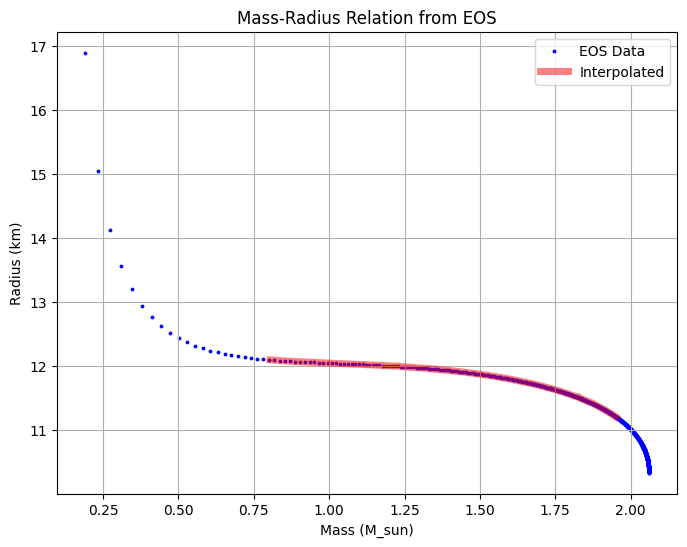

In [50]:
eos = pd.read_csv('eos.mr', names=['radius', 'mass'], sep='\s+', skiprows=1)

mass = eos['mass'].values
radius = eos['radius'].values
f = interp1d(mass, radius, kind='cubic', fill_value="extrapolate")
mass1 = np.sort(np.random.normal(1.4, 0.2, size=1000))
radius1 = f(mass1)

plt.figure(figsize=(8,6))
plt.scatter(mass, radius, label='EOS Data', color='b',s=3)
plt.plot(mass1, radius1, label='Interpolated', color='r', alpha=0.5, linewidth=5)
plt.xlabel('Mass (M_sun)')
plt.ylabel('Radius (km)')
plt.title('Mass-Radius Relation from EOS')
plt.legend()
plt.grid()

In [51]:
def compute_radius(mass, eos_file):
    eos = pd.read_csv(eos_file, names=['radius', 'mass'], sep='\s+', skiprows=1)
    mass_eos = eos['mass'].values
    radius_eos = eos['radius'].values
    f = interp1d(mass_eos, radius_eos, kind='cubic', fill_value="extrapolate")
    radius = f(mass)
    return radius

In [52]:
mass2 = injections['mass2'].values
mass1 = injections['mass1'].values

radius2 = np.around(f(mass2),decimals=6)
injections['radius2'] = radius2
radius2

array([11.841399, 11.666716, 11.564889, ..., 11.768622, 11.527173,
       11.942097])

In [53]:
def compute_compactness(mass, radius):

    G = 6.67430e-11  # m^3 kg^-1 s^-2
    c = 299792458    # m/s
    Ms = 1.98855e30  # kg
    C = (G * mass * Ms) / (c**2 * radius * 1000)  # radius in km to m
    return np.around(C, decimals=5)

compactness2 = compute_compactness(mass2, radius2)
injections['compactness2'] = compactness2

## Compute ejecta mass
In Bulla KN model, ejecta has two components: dynamical ejecta and wind ejecta. We can calculate them with gravitational wave parameters. 

Reference: *A multi-messenger model for neutron star - black hole mergers*

Compute total ejecta mass and dynamical mass, then $m_{disc}=m_{ej}-m_{dyn}$

For total ejecta mass, 
$M_{ej}=M_{NS}^{b}[max(\alpha \frac{1-2C_{NS}}{\eta^{1/3}}-\beta\hat{R}_{ISCO}\frac{C_{NS}}{\eta}+\gamma, 0)]$,

$M_{NS}^b=M_{NS}(1+\frac{0.6C_{NS}}{1-0.5C_{NS}})$,

$\hat{R}_{ISCO}=3+Z_2-sgn(\chi_{BH})\sqrt{(3-Z_1)(3+Z_1+2Z_2)}$，$Z_1=1+(1-\chi_{BH}^2)^{1/3}[(1+\chi_{BH})^{1/3}+(1-\chi_{BH})^{1/3}],Z_2=\sqrt{3\chi_{BH}^2+Z_1^2}$,$\chi_{BH}$ is the orbit-aligned component of the BH’s  dimensionless spin parameter

$\alpha=0.406,\beta=0.139,\gamma=0.255,\delta=1.761,\eta=\frac{1}{(1+1/q)^2q}$

In [54]:
def compute_R_ISCO(spinz_bh):
    z1 = 1 + (1-spinz_bh**2)**(1/3)*((1+spinz_bh)**(1/3)+(1-spinz_bh)**(1/3))
    z2 = np.sqrt(3*spinz_bh**2+z1**2)

    R_ISCO = 3 + z2 - np.sign(spinz_bh) * np.sqrt((3-z1)*(3+z1+2*z2))
    return R_ISCO


def total_ejecta_mass(mass_ns, mass_bh, c_ns, spinz_bh):
    a = 0.406
    b = 0.139
    gamma=0.255
    delta=1.761

    q = mass_ns / mass_bh
    eta = (1+1/q)**(-2) * q**(-1)

    R_ISCO = compute_R_ISCO(spinz_bh)

    mass_b_ns = mass_ns * (1 + 0.6*c_ns/(1-0.5*c_ns))

    term = a*(1-2*c_ns)/eta**(1/3) - b*R_ISCO*c_ns/eta + gamma
    mej_tot = mass_b_ns * np.where(term>0, term, 0)**delta
    
    return mej_tot

Dynamical Ejecta Mass(M_sun):
Minumum of mej_tot: 0.0
Maxmimum of mej_tot: 0.4486563103149208


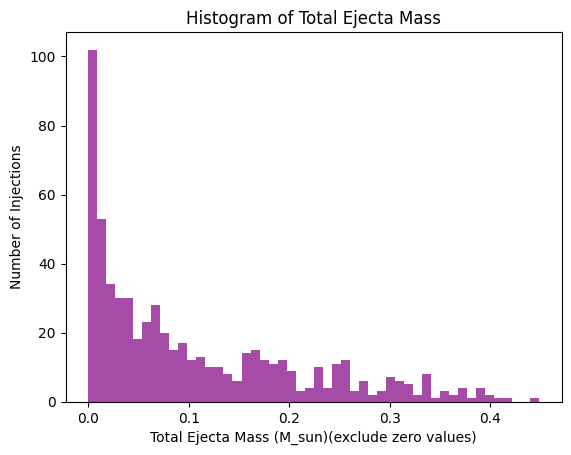

In [55]:
spinz_bh = injections['spin1z'].values
mej_tot = total_ejecta_mass(mass2, mass1, compactness2, spinz_bh)
injections['mej_tot'] = np.around(mej_tot, decimals=6)
print("Dynamical Ejecta Mass(M_sun):")
print("Minumum of mej_tot:", mej_tot.min())
print("Maxmimum of mej_tot:", mej_tot.max())
# total mass of ejecta
plt.hist(injections['mej_tot'], bins=50, range=(1e-6,mej_tot.max()), color='purple', alpha=0.7)
plt.xlabel('Total Ejecta Mass (M_sun)(exclude zero values)')
plt.ylabel('Number of Injections')
plt.title('Histogram of Total Ejecta Mass')
plt.show()

For dynamical ejcta mass:

$M_{dyn}=M_{NS}^b(a_1q^{-n_1}\frac{1-2C_{NS}}{C_{NS}}-a_2q^{-n_2}\frac{R_{ISCO}}{M_{BH}}+a_4)$,
$a_1=0.007116,a_2=0.001436,a_4=-0.02762,n_1=0.8636,n_2=1.6840$

In [56]:
def compute_dynamical_ejecta_mass(mass_ns, mass_bh, spinz_bh, c_ns):

    a1=0.007116
    a2=0.001436
    a4=-0.02762
    n1=0.8636
    n2=1.6840

    R_ISCO = compute_R_ISCO(spinz_bh)
    q = mass_ns / mass_bh
    mass_b_ns = mass_ns * (1 + 0.6*c_ns/(1-0.5*c_ns))

    mej_dyn = mass_b_ns * (a1*q**(-n1)*(1-2*c_ns)/c_ns - a2*q**(-n2)*R_ISCO/mass_bh + a4)
    return mej_dyn

Dynamical Ejecta Mass(M_sun):
[0.11066764 0.02273904 0.31347608 ... 0.31576981 0.09649109 0.12320524]
Minumum of mej_dyn: 0.0
Maxmimum of mej_dyn: 0.9352739990667259


Text(0.5, 1.0, 'Distribution of dynamical ejecta mass')

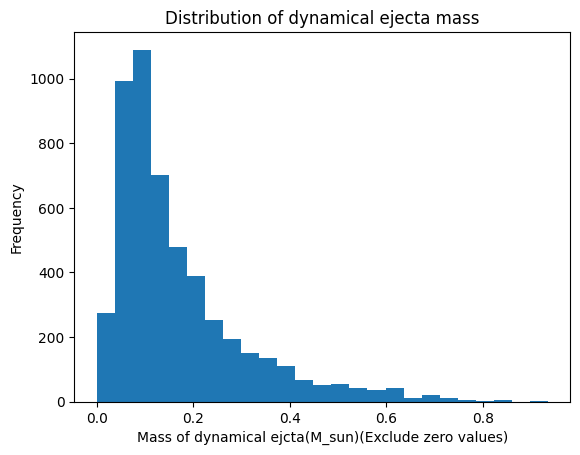

In [57]:
mej_dyn = compute_dynamical_ejecta_mass(mass2, mass1, spinz_bh, compactness2)
mej_dyn = np.where(mej_dyn>0, mej_dyn, 0)
injections['mej_dyn'] = np.around(mej_dyn, decimals=6)
print("Dynamical Ejecta Mass(M_sun):")
print(mej_dyn)
print("Minumum of mej_dyn:", mej_dyn.min())
print("Maxmimum of mej_dyn:", mej_dyn.max())
plt.hist(mej_dyn,bins=25, range=(1e-6, mej_dyn.max()))
plt.xlabel("Mass of dynamical ejcta(M_sun)(Exclude zero values)")
plt.ylabel("Frequency")
plt.title("Distribution of dynamical ejecta mass")

## Wind ejecta mass
$M_{disc}=M_{tot}-M_{dyn}$,

$\xi = \frac{M_{wind}}{M_{disc}}=\xi _1+\frac{\xi _2-\xi _1}{1+e^{1.5(1/q-3)}}$

$M_{wind} = \xi M_{disc}$, $\xi _1=0.18, \xi _2=0.29.$

In [58]:
def compute_wind_ejecta_mass(mej_tot, mej_dyn, q):
    mass_disc = np.where(mej_tot-mej_dyn>0, mej_tot-mej_dyn, 0)
    xi = 0.18 + 0.11 / (1+np.e**(1.5*(1/q-3)))
    mej_wind = xi * mass_disc
    return mej_wind

Wind ejecta mass: [0.         0.         0.         ... 0.         0.         0.00648133]
Minumum of mej_wind: 0.0
Maxmimum of mej_wind: 0.0781160763990947


Text(0.5, 1.0, 'Distribution of wind ejecta mass')

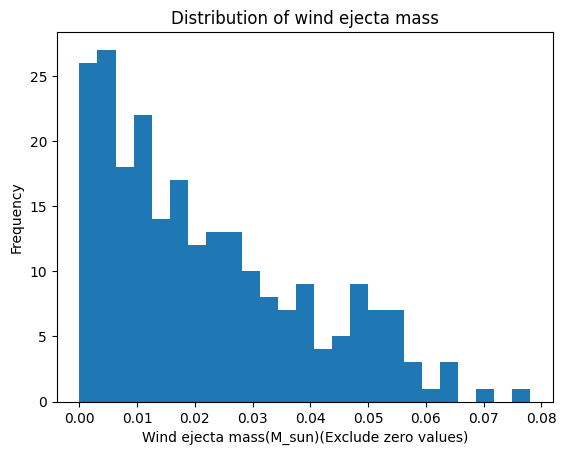

In [59]:
q = mass2/mass1
mej_wind = compute_wind_ejecta_mass(mej_tot, mej_dyn, q)
injections['mej_wind'] = np.around(mej_wind, decimals=6)
print("Wind ejecta mass:", mej_wind)
print("Minumum of mej_wind:", mej_wind.min())
print("Maxmimum of mej_wind:", mej_wind.max())
plt.hist(mej_wind, bins=25, range=(1e-6,mej_wind.max()))
plt.xlabel("Wind ejecta mass(M_sun)(Exclude zero values)")
plt.ylabel("Frequency")
plt.title("Distribution of wind ejecta mass")

Save new injections parameters.

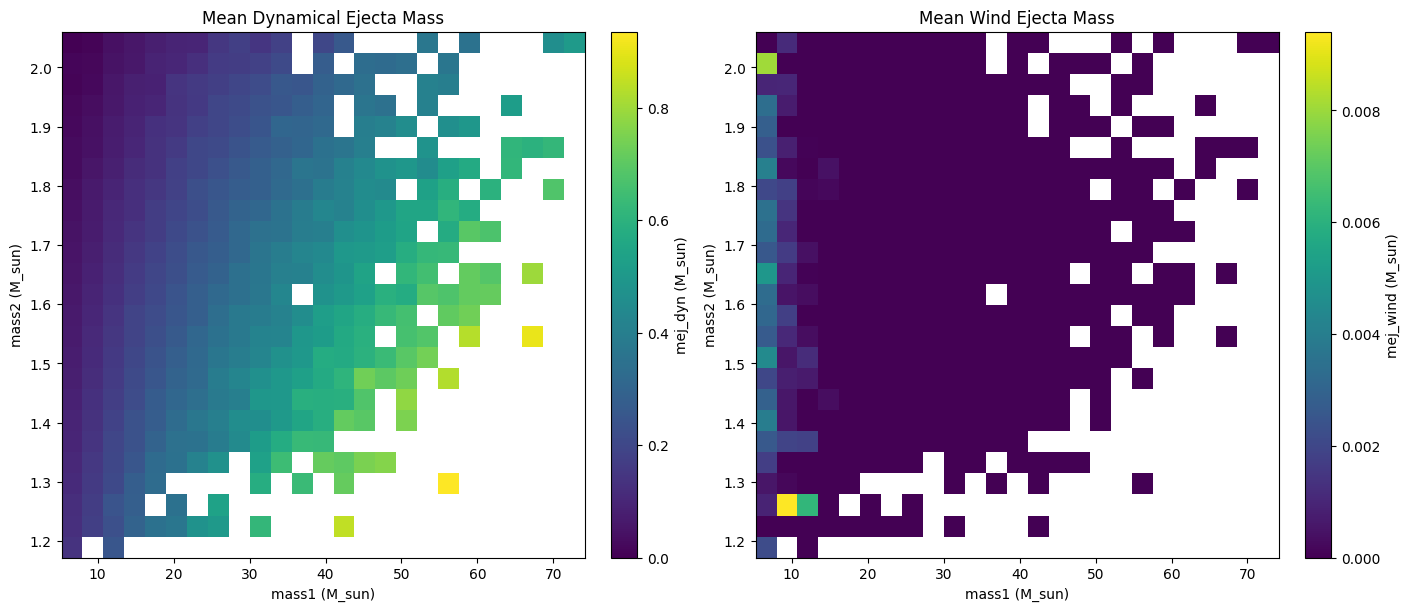

In [60]:
# Heatmaps of ejecta masses vs (mass1, mass2)
bins = 25

# 2D mean for dynamical ejecta
H_sum_dyn, xedges, yedges = np.histogram2d(mass1, mass2, bins=bins, weights=mej_dyn)
H_count, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges])
H_mean_dyn = H_sum_dyn / np.where(H_count == 0, np.nan, H_count)

# 2D mean for wind ejecta
H_sum_wind, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges], weights=mej_wind)
H_mean_wind = H_sum_wind / np.where(H_count == 0, np.nan, H_count)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axs[0].pcolormesh(xedges, yedges, H_mean_dyn.T, cmap='viridis', shading='auto')
axs[0].set_xlabel('mass1 (M_sun)')
axs[0].set_ylabel('mass2 (M_sun)')
axs[0].set_title('Mean Dynamical Ejecta Mass')
c0 = fig.colorbar(im0, ax=axs[0])
c0.set_label('mej_dyn (M_sun)')

im1 = axs[1].pcolormesh(xedges, yedges, H_mean_wind.T, cmap='viridis', shading='auto')
axs[1].set_xlabel('mass1 (M_sun)')
axs[1].set_ylabel('mass2 (M_sun)')
axs[1].set_title('Mean Wind Ejecta Mass')
c1 = fig.colorbar(im1, ax=axs[1])
c1.set_label('mej_wind (M_sun)')

plt.show()

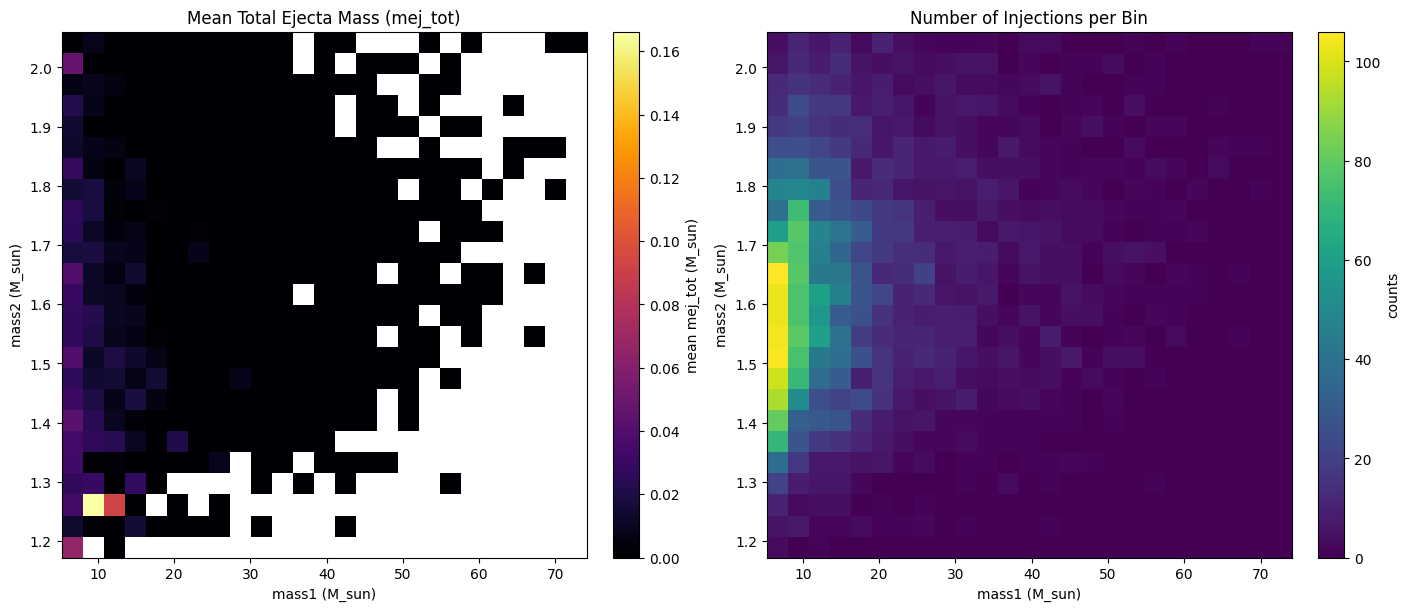

In [61]:
# 2D mean (and count) of total ejecta mass vs (mass1, mass2)
bins = 25

H_sum, xedges, yedges = np.histogram2d(mass1, mass2, bins=bins, weights=mej_tot)
H_count, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges])
H_mean = H_sum / np.where(H_count == 0, np.nan, H_count)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axs[0].pcolormesh(xedges, yedges, H_mean.T, cmap='inferno', shading='auto')
axs[0].set_xlabel('mass1 (M_sun)')
axs[0].set_ylabel('mass2 (M_sun)')
axs[0].set_title('Mean Total Ejecta Mass (mej_tot)')
c0 = fig.colorbar(im0, ax=axs[0])
c0.set_label('mean mej_tot (M_sun)')

# show counts in the other panel
im1 = axs[1].pcolormesh(xedges, yedges, H_count.T, cmap='viridis', shading='auto')
axs[1].set_xlabel('mass1 (M_sun)')
axs[1].set_ylabel('mass2 (M_sun)')
axs[1].set_title('Number of Injections per Bin')
c1 = fig.colorbar(im1, ax=axs[1])
c1.set_label('counts')

plt.show()

Add half-opening angle($\Phi$) and observing angle($Cos\Theta$).

$\Phi \in U(15^o, 75^o)$, $\Theta=min(\iota, \pi-\iota)$ 

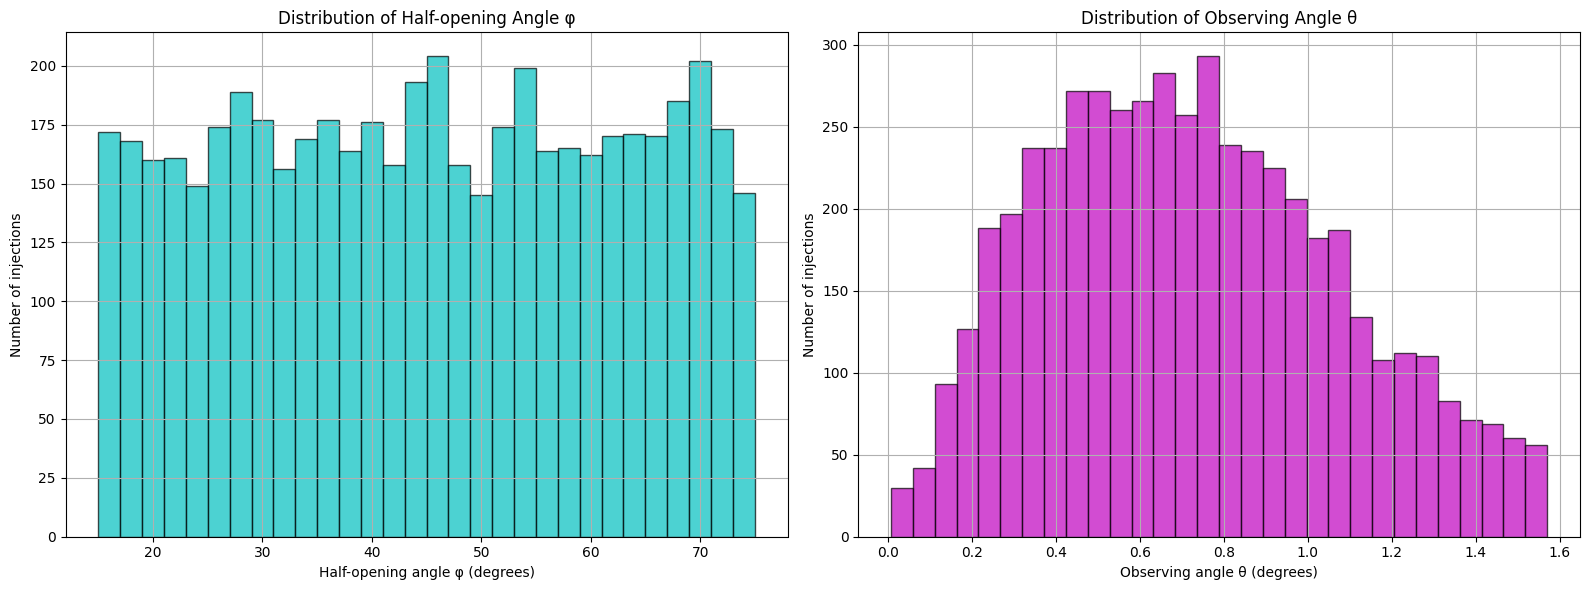

In [62]:
# half-opening angle phi
phi = np.random.uniform(15, 75, size=len(mass1))

# observing angle theta
inclination = injections['inclination'].values
theta = np.where(inclination <= np.pi/2, inclination, (np.pi - inclination))

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.hist(phi, bins=30, color='c', edgecolor='k', alpha=0.7)
plt.xlabel('Half-opening angle φ (degrees)')
plt.ylabel('Number of injections')
plt.title('Distribution of Half-opening Angle φ')
plt.grid()
plt.subplot(1,2,2)
plt.hist(theta, bins=30, color='m', edgecolor='k', alpha=0.7)
plt.xlabel('Observing angle θ (degrees)')
plt.ylabel('Number of injections')
plt.title('Distribution of Observing Angle θ')
plt.grid()
plt.tight_layout()

injections['phi'] = np.around(phi, decimals=6)
injections['costheta'] = np.around(np.cos(theta), decimals=6)

### Add distance and uncertainty in skymap.

In [63]:
ra = np.rad2deg(injections['longitude'].values)
dec = np.rad2deg(injections['latitude'].values)

injections['ra'] = np.around(ra, decimals=6)
injections['dec'] = np.around(dec, decimals=6)

In [64]:
distmean = allsky['distmean'].values
diststd = allsky['diststd'].values

injections['distmean'] = np.around(distmean, decimals=6)
injections['diststd'] = np.around(diststd, decimals=6)

In [65]:
# add GPS time and mjd time columns
mjd_min = 61000.0
mjd_max = 64500.0
mjd_times = np.random.uniform(mjd_min, mjd_max, size=len(injections))
gps_times = Time(mjd_times, format='mjd').gps

injections['mjd_time'] = np.around(mjd_times, decimals=4)
injections['gps_time'] = np.around(gps_times, decimals=2)

/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 3422 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [66]:
# re-order columns
cols = list(injections.columns)
cols.insert(1, cols.pop(cols.index('mjd_time')))
cols.insert(2, cols.pop(cols.index('gps_time')))
cols.insert(5, cols.pop(cols.index('ra')))
cols.insert(6, cols.pop(cols.index('dec')))

injections = injections[cols]
print(injections.columns)

Index(['simulation_id', 'mjd_time', 'gps_time', 'longitude', 'latitude', 'ra',
       'dec', 'inclination', 'distance', 'mass1', 'mass2', 'spin1z', 'spin2z',
       'radius2', 'compactness2', 'mej_tot', 'mej_dyn', 'mej_wind', 'phi',
       'costheta', 'distmean', 'diststd'],
      dtype='object')


In [69]:
index = np.where(np.logical_and(injections['mej_wind']>0,injections['mej_dyn']>0))[0]
print(len(index))

237


In [67]:
injections.to_csv('injections_final.csv', index=False)